In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\abiav\Machine_learning_project\K-Mean Clustering\income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


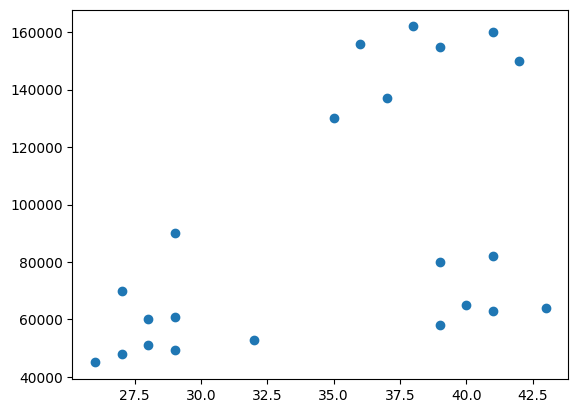

In [3]:
plt.scatter(df["Age"],df['Income($)'])

In [4]:
km=KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [5]:
y_predict=km.fit_predict(df[["Age","Income($)"]])
y_predict

C:\Users\abiav\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abiav\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\abiav\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\abiav\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\abia

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [6]:
df['cluster']=y_predict
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


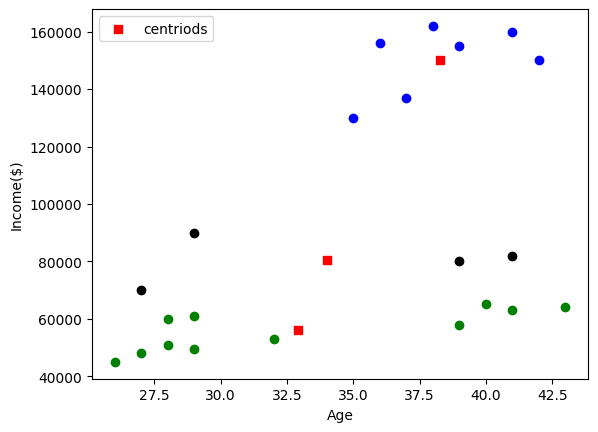

In [7]:
n1=df[df.cluster==0]
n2=df[df.cluster==1]
n3=df[df.cluster==2]
plt.scatter(n1.Age,n1["Income($)"],color="Green")
plt.scatter(n2.Age,n2["Income($)"],color="blue")
plt.scatter(n3.Age,n3["Income($)"],color="black")
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color="Red",marker=",",label="centriods")
plt.xlabel('Age')
plt.ylabel("Income($)")
plt.legend()

In [8]:
Scaler = MinMaxScaler()
Scaler.fit(df[["Income($)"]])
df["Income($)"]=Scaler.transform(df[["Income($)"]])
df
Scaler = MinMaxScaler()
Scaler.fit(df[["Age"]])
df["Age"]=Scaler.transform(df[["Age"]])
df


,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [9]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df[['Age','Income($)']])
y_predicted

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

In [10]:
df['cluster']=y_predicted
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,2
5,Gautam,0.764706,0.940171,2
6,David,0.882353,0.982906,2
7,Andrea,0.705882,1.000000,2
8,Brad,0.588235,0.948718,2
9,Angelina,0.529412,0.726496,2


In [11]:
km.cluster_centers_

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

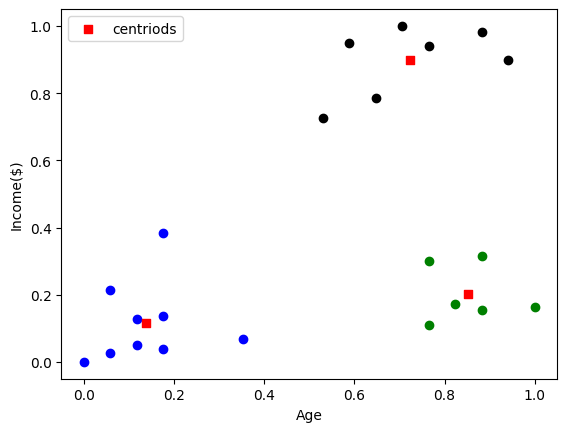

In [12]:
n1=df[df.cluster==0]
n2=df[df.cluster==1]
n3=df[df.cluster==2]
plt.scatter(n1.Age,n1["Income($)"],color="Green")
plt.scatter(n2.Age,n2["Income($)"],color="blue")
plt.scatter(n3.Age,n3["Income($)"],color="black")
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color="Red",marker=",",label="centriods")
plt.xlabel('Age')
plt.ylabel("Income($)")
plt.legend()

In [13]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


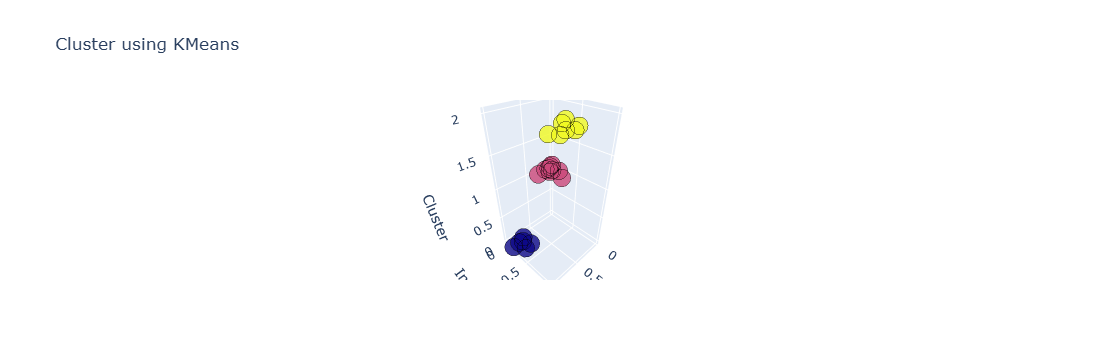

In [14]:
import plotly as py
import plotly.graph_objs as go

trace1 = go.Scatter3d(
    x=df["Age"],
    y=df["Income($)"],
    z=df["cluster"], 
    mode="markers",
    marker=dict(
        color=df["cluster"],
        size=10,
        line=dict(
            color='black',
            width=1
        ),
        opacity=0.8
    )
)

data = [trace1]

layout = go.Layout(
    title="Cluster using KMeans",
    scene=dict(
        xaxis=dict(title="Age"),
        yaxis=dict(title="Income($)"),
        zaxis=dict(title="Cluster")
    )
)

fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)
